In [13]:
train_set = '../../data/raw/sample_23.csv' # do not touch
test_set = '../../data/raw/sample_24.csv' # do not touch

predictions_clustering = {
    # '../data/predictions/tft_case5_clusters_wide.csv': "outputs/feature/case5_clusters.csv",
    # '../data/predictions/tft_case2_clusters_wide.csv': "outputs/feature/case2_clusters.csv",
    # '../data/predictions/sklearn_forecast_2024_cluster_specific_combined_case1_clusters.csv': "outputs/feature/case1_clusters.csv",
    # '../data/predictions/sklearn_forecast_2024_cluster_specific_combined_case2_clusters.csv': "outputs/feature/case2_clusters.csv",
    # '../data/predictions/sklearn_forecast_2024_cluster_specific_combined_case3_clusters.csv': "outputs/feature/case3_clusters.csv",
    # '../data/predictions/sklearn_forecast_2024_cluster_specific_combined_case4_clusters.csv': "outputs/feature/case4_clusters.csv",
    # '../data/predictions/sklearn_forecast_2024_cluster_specific_combined_case5_clusters.csv': "outputs/feature/case5_clusters.csv",
    # '../data/predictions/sklearn_forecast_2024_cluster_specific_combined_case6_clusters.csv': "outputs/feature/case6_clusters.csv",
    # '../data/predictions/flo/pred_2024_cluster_xgb(1).csv': "outputs/feature/case1_clusters.csv",
    # '../data/predictions/flo/pred_2024_cluster_xgb(2).csv': "outputs/feature/case2_clusters.csv",
    # '../data/predictions/flo/pred_2024_cluster_xgb(3).csv': "outputs/feature/case3_clusters.csv",
    # '../data/predictions/flo/pred_2024_cluster_xgb(4).csv': "outputs/feature/case4_clusters.csv",
    # '../data/predictions/flo/pred_2024_cluster_xgb(5).csv': "outputs/feature/case5_clusters.csv",
    # 'outputs/pred_combined_case5.csv': "outputs/feature/case5_clusters.csv",
    '../../data/predictions/weighted_average_predictions.csv': "../outputs/feature/case5_clusters.csv",
    # 'outputs/pred_2024_cluster_xgb(13).csv': "outputs/feature/case5_clusters.csv",
    # 'outputs/pred_2024_global_xgb(1).csv': None,
    # '../data/predictions/flo/pred_2024_cluster_xgb(6).csv': "outputs/feature/case6_clusters.csv",
    # '../data/predictions/flo_static_shapelets/pred_2024_cluster_xgb(7).csv': "outputs/feature/case1_clusters.csv",
    # '../data/predictions/flo_static_shapelets/pred_2024_cluster_xgb(8).csv': "outputs/feature/case2_clusters.csv",
    # '../data/predictions/flo_static_shapelets/pred_2024_cluster_xgb(9).csv': "outputs/feature/case3_clusters.csv",
    # '../data/predictions/flo_static_shapelets/pred_2024_cluster_xgb(10).csv': "outputs/feature/case4_clusters.csv",
    # '../data/predictions/flo_static_shapelets/pred_2024_cluster_xgb(11).csv': "outputs/feature/case5_clusters.csv",
    # '../data/predictions/flo_static_shapelets/pred_2024_cluster_xgb(12).csv': "outputs/feature/case6_clusters.csv",
}


=== weighted_average_predictions ===
Prediction file: /home/gopes/Documents/Clustering-And-Forecasting-TimeSeries-PlayingGround/data/predictions/weighted_average_predictions.csv
Cluster file: /home/gopes/Documents/Clustering-And-Forecasting-TimeSeries-PlayingGround/notebooks/outputs/feature/case5_clusters.csv
Rows evaluated: 6,422,202
Overall MAE: 3.253904
Overall MAPE: 426.118640%
Metrics by cluster:
 RefinedCluster      mae         mape
             -1 0.080628    99.863994
              2 2.224536   237.350134
              0 3.508514   327.388191
              3 3.195402   348.296516
              5 7.642247   482.171824
              1 4.884960   534.217350
              4 2.296152  1795.832524
              6 1.816558  1883.370301
              8 1.361846  2897.322982
              7 3.780235  5732.947735
              9 5.775334 11675.094368


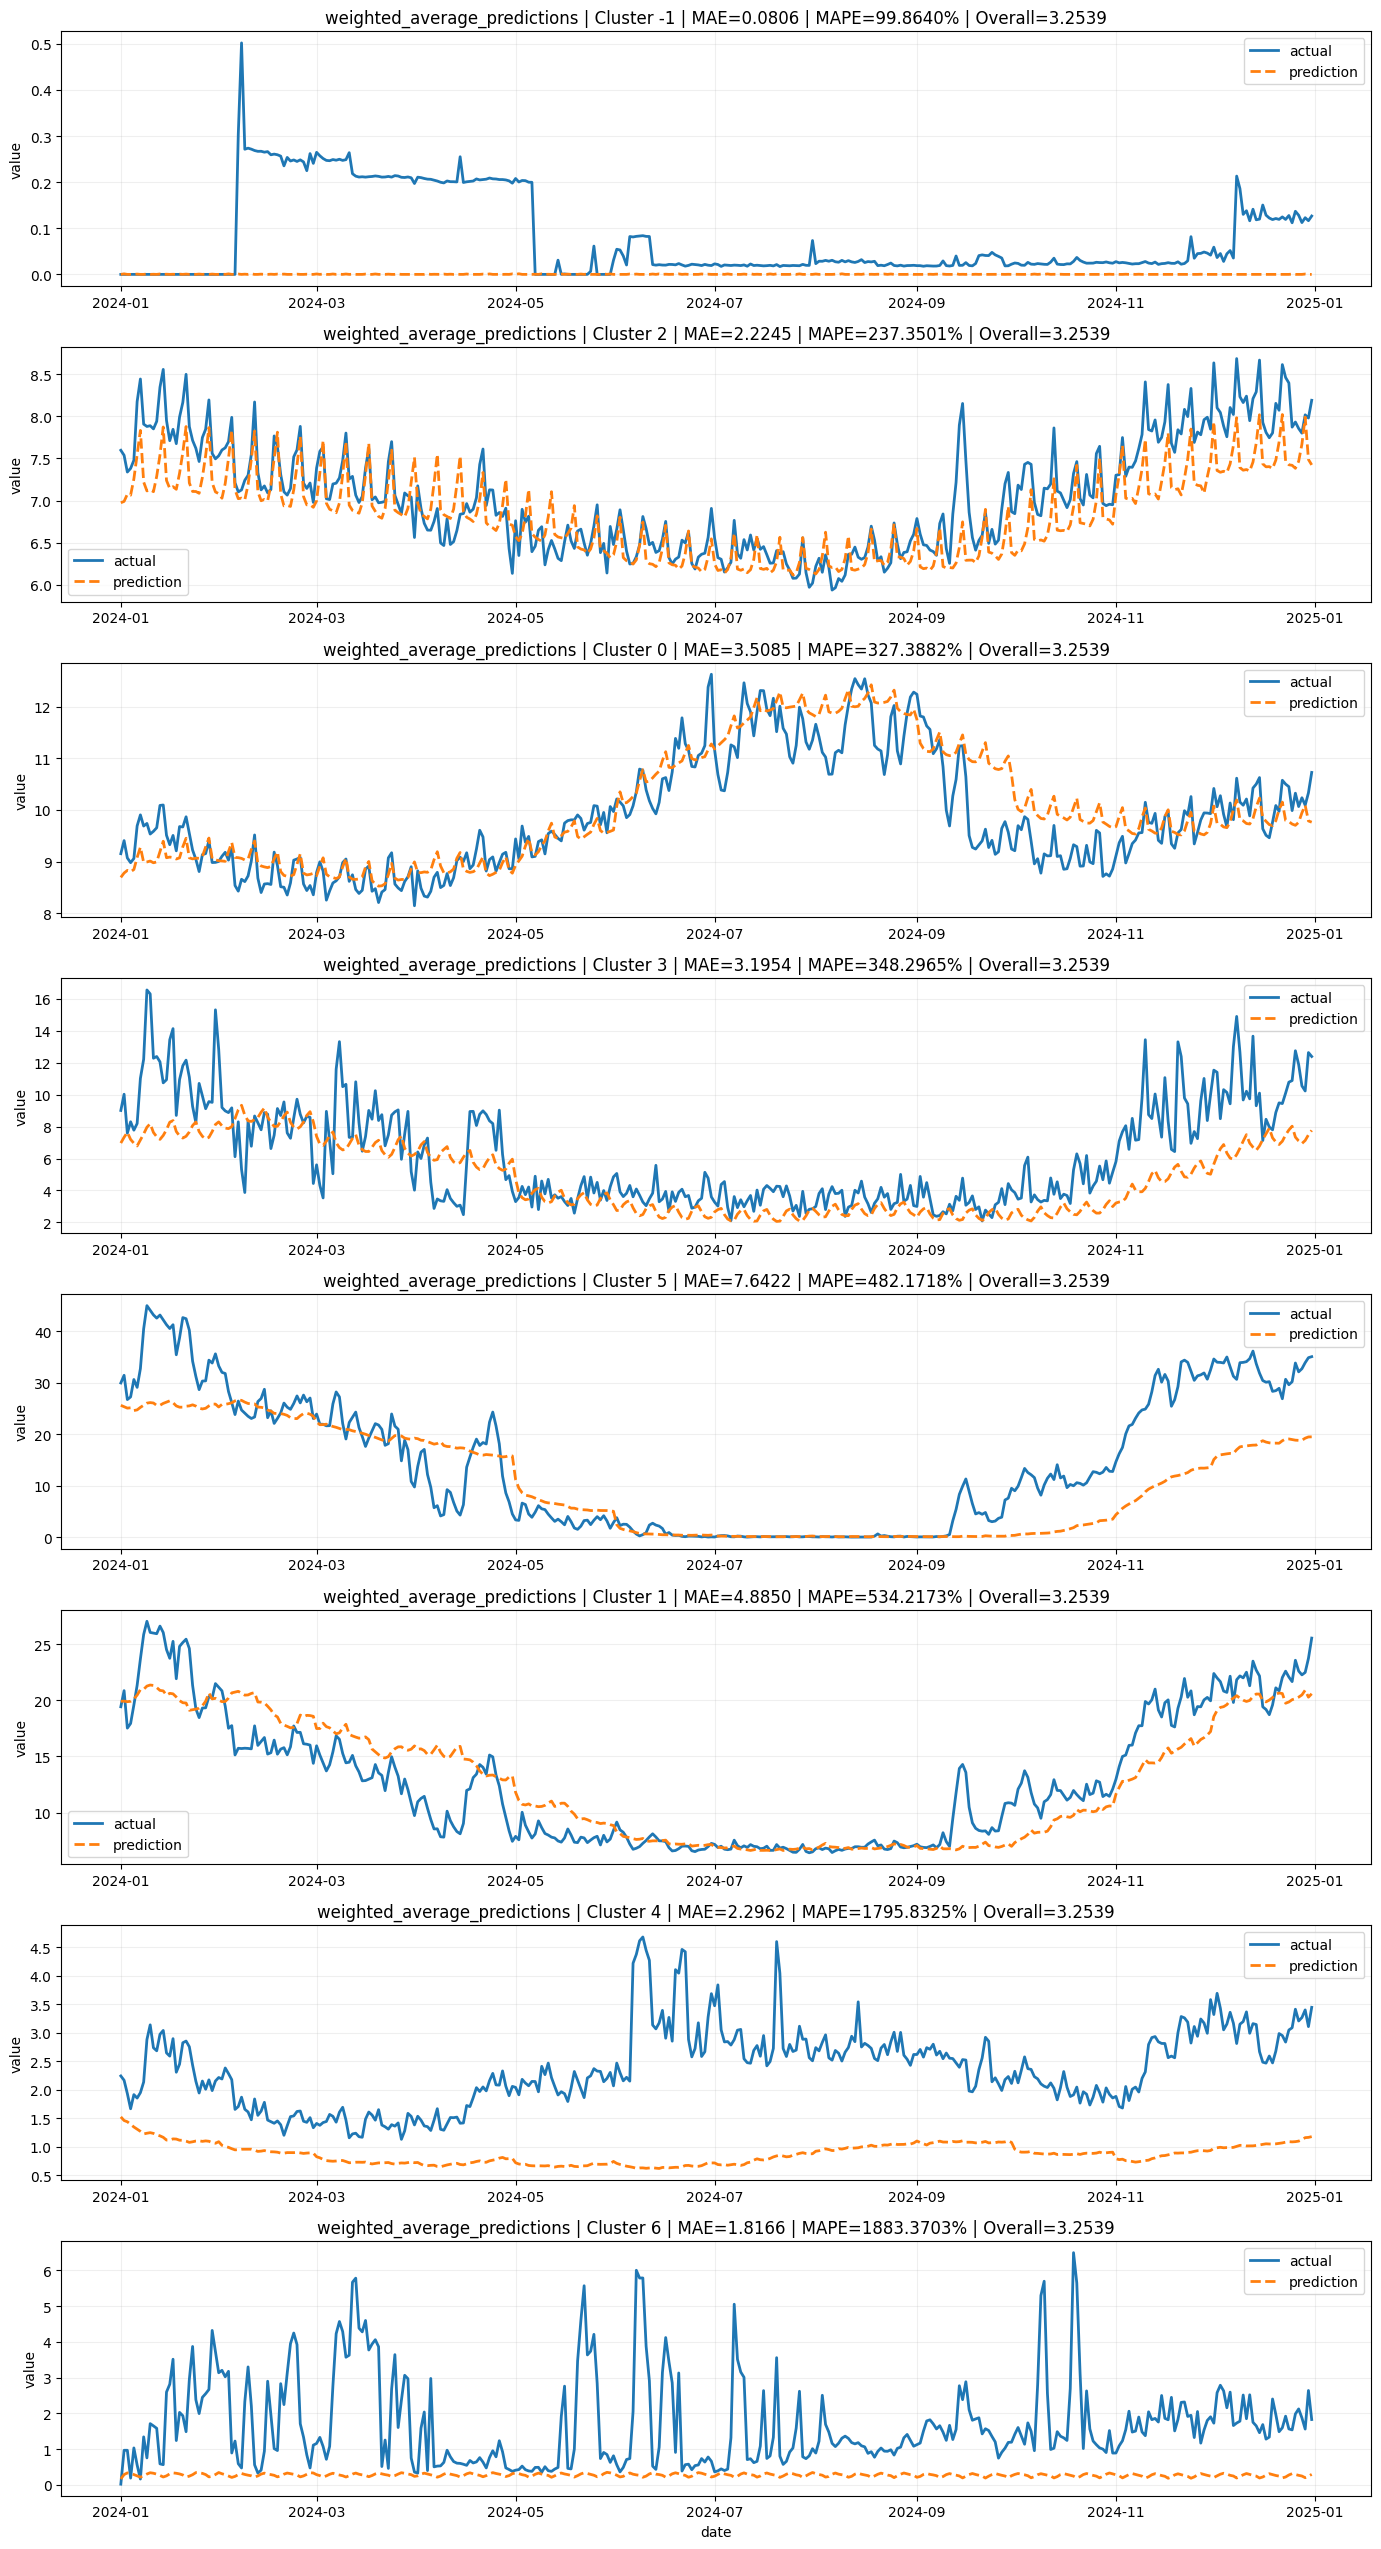


=== Summary Across Cases ===
                        case  overall_mae  overall_mape  n_pairs
weighted_average_predictions     3.253904     426.11864  6422202


In [15]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error

import matplotlib.pyplot as plt


def _resolve_path(path_like, base_dir):
    p = Path(path_like)
    if p.is_absolute():
        return p
    return (base_dir / p).resolve()


def _pick_id_col(df_a, df_b):
    candidates = ["ID", "id", "series_id", "item_id"]
    for c in candidates:
        if c in df_a.columns and c in df_b.columns:
            return c
    common = set(df_a.columns).intersection(df_b.columns)
    if common:
        return sorted(common)[0]
    raise ValueError("No common identifier column found between evaluation and prediction dataframes.")


def _is_date_like_col(name):
    try:
        pd.to_datetime(name, errors="raise")
        return True
    except Exception:
        return False


def _pick_value_cols(eval_df, pred_df, id_col):
    common = [c for c in eval_df.columns if c in pred_df.columns and c != id_col]

    date_like = [c for c in common if _is_date_like_col(c)]
    if date_like:
        return date_like

    numeric_common = []
    for c in common:
        if pd.api.types.is_numeric_dtype(eval_df[c]) and pd.api.types.is_numeric_dtype(pred_df[c]):
            numeric_common.append(c)

    if not numeric_common:
        raise ValueError("No common value columns found between evaluation and prediction files.")
    return numeric_common


def _pick_cluster_col(cluster_df):
    if cluster_df is None:
        return None
    candidates = ["cluster", "cluster_id", "Cluster", "CLUSTER", "label", "labels", "RefinedCluster"]
    for c in candidates:
        if c in cluster_df.columns:
            return c
    for c in cluster_df.columns:
        lc = c.lower()
        if "cluster" in lc or lc in {"label", "labels"}:
            return c
    return None


def _safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    nonzero_mask = np.abs(y_true) > 0
    if not np.any(nonzero_mask):
        return np.nan
    return np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100.0


def _load_case_data(eval_df, pred_path, cluster_path=None):
    pred_df = pd.read_csv(pred_path)

    id_col = _pick_id_col(eval_df, pred_df)
    value_cols = _pick_value_cols(eval_df, pred_df, id_col)

    eval_part = eval_df[[id_col] + value_cols].copy()
    pred_part = pred_df[[id_col] + value_cols].copy()

    merged = eval_part.merge(
        pred_part,
        on=id_col,
        how="inner",
        suffixes=("_true", "_pred"),
    )

    if merged.empty:
        raise ValueError(f"No overlapping IDs after merge for prediction file: {pred_path}")

    cluster_col = None
    if cluster_path is not None and Path(cluster_path).exists():
        cluster_df = pd.read_csv(cluster_path)
        cluster_id_col = id_col if id_col in cluster_df.columns else _pick_id_col(eval_part, cluster_df)
        cluster_col = _pick_cluster_col(cluster_df)

        if cluster_col is not None:
            merged = merged.merge(
                cluster_df[[cluster_id_col, cluster_col]].rename(columns={cluster_id_col: id_col}),
                on=id_col,
                how="left",
            )

    return merged, id_col, value_cols, cluster_col


def _build_long_df(merged_df, value_cols, cluster_col):
    true_cols = [f"{c}_true" for c in value_cols]
    pred_cols = [f"{c}_pred" for c in value_cols]

    true_long = merged_df.melt(
        id_vars=[cluster_col] if cluster_col else None,
        value_vars=true_cols,
        var_name="date_col",
        value_name="y_true",
    )
    pred_long = merged_df.melt(
        id_vars=[cluster_col] if cluster_col else None,
        value_vars=pred_cols,
        var_name="date_col",
        value_name="y_pred",
    )

    true_long["date_col"] = true_long["date_col"].str.replace("_true", "", regex=False)
    pred_long["date_col"] = pred_long["date_col"].str.replace("_pred", "", regex=False)

    long_df = true_long.copy()
    long_df["y_pred"] = pred_long["y_pred"].to_numpy()
    long_df["date"] = pd.to_datetime(long_df["date_col"], errors="coerce")

    if cluster_col is None:
        long_df["_cluster_tmp_"] = "all"
        cluster_col = "_cluster_tmp_"

    return long_df, cluster_col


def _evaluate_one_case(case_name, eval_df, pred_path, cluster_path):
    merged, _, value_cols, cluster_col = _load_case_data(eval_df, pred_path, cluster_path)
    long_df, cluster_col = _build_long_df(merged, value_cols, cluster_col)

    long_df = long_df.dropna(subset=["y_true", "y_pred"]).copy()
    if long_df.empty:
        raise ValueError(f"No valid numeric pairs to evaluate for case: {case_name}")

    overall_mae = mean_absolute_error(long_df["y_true"], long_df["y_pred"])
    overall_mape = _safe_mape(long_df["y_true"], long_df["y_pred"])
    by_cluster = (
        long_df.groupby(cluster_col)
        .apply(lambda d: pd.Series({
            "mae": mean_absolute_error(d["y_true"], d["y_pred"]),
            "mape": _safe_mape(d["y_true"], d["y_pred"]),
        }))
        .reset_index()
        .sort_values(["mape", "mae"], na_position="last")
    )

    print(f"\n=== {case_name} ===")
    print(f"Prediction file: {pred_path}")
    print(f"Cluster file: {cluster_path if cluster_path else 'None'}")
    print(f"Rows evaluated: {len(long_df):,}")
    print(f"Overall MAE: {overall_mae:.6f}")
    print(f"Overall MAPE: {overall_mape:.6f}%")
    print("Metrics by cluster:")
    print(by_cluster.to_string(index=False))

    clusters = by_cluster[cluster_col].tolist()
    n_plots = min(len(clusters), 8)

    fig, axes = plt.subplots(n_plots, 1, figsize=(14, 3.2 * n_plots), squeeze=False)
    for i, c in enumerate(clusters[:n_plots]):
        ax = axes[i, 0]
        d = long_df[long_df[cluster_col] == c]
        daily = d.groupby("date", dropna=False)[["y_true", "y_pred"]].mean().reset_index()

        x = daily["date"] if daily["date"].notna().any() else np.arange(len(daily))
        ax.plot(x, daily["y_true"], label="actual", linewidth=2)
        ax.plot(x, daily["y_pred"], label="prediction", linewidth=2, linestyle="--")
        row = by_cluster.loc[by_cluster[cluster_col] == c].iloc[0]
        ax.set_title(f"{case_name} | Cluster {c} | MAE={row['mae']:.4f} | MAPE={row['mape']:.4f}% | Overall={overall_mae:.4f}")
        ax.set_ylabel("value")
        ax.grid(alpha=0.2)
        ax.legend()

    axes[-1, 0].set_xlabel("date")
    plt.tight_layout()
    plt.show()

    return {
        "case": case_name,
        "overall_mae": overall_mae,
        "overall_mape": overall_mape,
        "n_pairs": len(long_df),
    }


NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "notebooks":
    # If the notebook runs from project root, this still resolves correctly.
    NOTEBOOK_DIR = (Path.cwd() / "notebooks") if (Path.cwd() / "notebooks").exists() else Path.cwd()

eval_df = pd.read_csv(_resolve_path(test_set, NOTEBOOK_DIR))

if not isinstance(predictions_clustering, dict) or len(predictions_clustering) == 0:
    raise ValueError("predictions_clustering must be a non-empty dict of {prediction_csv_path: cluster_csv_path_or_None}.")

results = []
for pred_rel, cluster_rel in predictions_clustering.items():
    pred_path = _resolve_path(pred_rel, NOTEBOOK_DIR)
    cluster_path = _resolve_path(cluster_rel, NOTEBOOK_DIR) if isinstance(cluster_rel, str) else None

    if not pred_path.exists():
        raise FileNotFoundError(f"Prediction file not found: {pred_path}")

    case_name = pred_path.stem
    result = _evaluate_one_case(case_name, eval_df, pred_path, cluster_path)
    results.append(result)

summary_df = pd.DataFrame(results).sort_values("overall_mae")
print("\n=== Summary Across Cases ===")
print(summary_df.to_string(index=False))